In [ ]:
import pandas as pd

In [ ]:
emotion_df = pd.read_csv('/content/emotion.csv')

In [ ]:
emotion_df.head()

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4


In [ ]:
hate_df = pd.read_csv('/content/hate_speech.csv')

In [ ]:
hate_df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
# DATA PREPROCESSING
# DROPPING UNWANTED COLUMNS
emotion_df.drop(columns = ['Unnamed: 0'], inplace = True)
hate_df = hate_df[['tweet','class']]

In [ ]:
emotion_df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [ ]:
hate_df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [ ]:
emotion_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['tweet', 'class'], dtype='object'))

In [ ]:
hate_df.rename(columns = {'tweet':'text', 'class':'label'}, inplace = True)

In [ ]:
emotion_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'))

In [ ]:
# CHECKING FOR NULL VALUES
emotion_df.isna().sum(), hate_df.isna().sum()

(text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

In [ ]:
emotion_df.shape, hate_df.shape

((416809, 2), (24783, 2))

In [ ]:
# EXTRACTING EQUAL NUMBER OF ROWS FROM BOTH THE DATASET
e_df = pd.DataFrame()
for i in range(6):
  subset = emotion_df[emotion_df['label'] == i].sample(n = 3000, random_state = 24)
  e_df = pd.concat([e_df, subset])

In [ ]:
e_df.shape

(18000, 2)

In [ ]:
emotion_df = e_df.copy()

In [ ]:
emotion_df['label'].value_counts()

,count
label,
0,3000
1,3000
2,3000
3,3000
4,3000
5,3000


In [ ]:
hate_df['label'].value_counts()

,count
label,
1,19190
2,4163
0,1430


In [ ]:
# very imbalanced dataset therefore we wiil take all the labels from 0 and 2 and the remaining from 1 to make it 18000

offensive_speech = hate_df[hate_df['label'] == 1].sample(n = 12407, random_state = 24)
hate_df = hate_df[hate_df['label'] != 1]

In [ ]:
hate_df.shape

(5593, 2)

In [ ]:
hate_df = pd.concat([offensive_speech, hate_df], axis = 0)

In [ ]:
hate_df.shape

(18000, 2)

In [ ]:
emotion_df.shape, hate_df.shape

((18000, 2), (18000, 2))

In [ ]:
emotion_df.head(3)

,text,label
234089,i put out or time or love or dedication i feel...,0
416027,i pray for my friend s salvation it feels like...,0
218515,i could probably manage the ii class now but f...,0


In [ ]:
hate_df.head(3)

,text,label
23342,You know a bitch mad when she throw her drink ...,1
16362,RT @Males_Thoughts: No bitch ass chick flick w...,1
366,"""@midyWIDEY_: I'm rea start smacking bitches p...",1


In [ ]:
# RESETTING THE INDEXES
emotion_df.reset_index(drop = True, inplace = True)
hate_df.reset_index(drop = True, inplace = True)

In [ ]:
emotion_df.head(3)

,text,label
0,i put out or time or love or dedication i feel...,0
1,i pray for my friend s salvation it feels like...,0
2,i could probably manage the ii class now but f...,0


In [ ]:
hate_df.head(3)

,text,label
0,You know a bitch mad when she throw her drink ...,1
1,RT @Males_Thoughts: No bitch ass chick flick w...,1
2,"""@midyWIDEY_: I'm rea start smacking bitches p...",1


In [ ]:
# STOPWORDS REMOVAL
import nltk
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
from nltk.tokenize import word_tokenize
def remove_stopwords(text):
  all_words = word_tokenize(text)
  filtered_words = [word for word in all_words if word.lower() not in stop_words]
  return ' '.join(filtered_words)

emotion_df['text'] = emotion_df['text'].apply(remove_stopwords)
hate_df['text'] = hate_df['text'].apply(remove_stopwords)

In [ ]:
emotion_df.head(3)

,text,label
0,put time love dedication feel pathetic,0
1,pray friend salvation feels like vain,0
2,could probably manage ii class moment im enjoy...,0


In [ ]:
hate_df.head(3)

,text,label
0,know bitch mad throw drink & # 128514 ; got fi...,1
1,RT @ Males_Thoughts : bitch ass chick flick ev...,1
2,`` @ midyWIDEY_ : 'm rea start smacking bitche...,1


In [ ]:
# TOKENIZATION AND PADDING(all the sentences have different number of words)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(pd.concat([emotion_df['text'],hate_df['text']]))

In [ ]:
emotion_sequences = tokenizer.texts_to_sequences(emotion_df['text'])
hate_sequences = tokenizer.texts_to_sequences(hate_df['text'])

In [ ]:
emotion_df ['text'].iloc[2]

'could probably manage ii class moment im enjoying feeling dumb lost left behind'

In [ ]:
emotion_sequences[2:3]

[[59, 300, 1826, 6832, 324, 331, 6, 1408, 2, 245, 257, 141, 607]]

In [ ]:
max_length = 50
emotion_padded = pad_sequences(emotion_sequences, maxlen = max_length, padding = 'post')
hate_padded = pad_sequences(hate_sequences, maxlen = max_length, padding = 'post')

In [ ]:
emotion_padded[2:3]

array([[  59,  300, 1826, 6832,  324,  331,    6, 1408,    2,  245,  257,
         141,  607,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0]], dtype=int32)

In [ ]:
# we are converting all the labels to numpy array format

import numpy as np
emotion_labels = np.array(emotion_df['label'])
hate_labels = np.array(hate_df['label'])

In [ ]:
# MODEL DEFINITION
# prepare separate inputs for each dataset

emotion_input = emotion_padded
hate_input = hate_padded


In [ ]:
# DEFINING MULTIPLE INPUT LAYERS FOR EACH TASK

from tensorflow import keras
emotion_input_layer = keras.layers.Input(shape = (max_length,), name = 'emotion_input')
hate_input_layer = keras.layers.Input(shape = (max_length,), name = 'hate_input')

In [ ]:
# SHARED EMBEDDING LAYER
embedding_layer = keras.layers.Embedding(input_dim = len(tokenizer.word_index)+1, output_dim = 128)

In [ ]:
# APPLYING THE EMBEDDING LAYER TO EACH INPUT
emotion_embedding = embedding_layer(emotion_input_layer)
hate_embedding = embedding_layer(hate_input_layer)

In [ ]:
# SHARED LSTM LAYER
shared_lstm = keras.layers.LSTM(64, return_sequences = True)

In [ ]:
emotion_lstm = shared_lstm(emotion_embedding)
hate_lstm = shared_lstm(hate_embedding)

In [ ]:
# SHARED GLOBAL AVERAGE POOLING LAYER AND DROPOUT LAYER
shared_pooling = keras.layers.GlobalAveragePooling1D()
shared_dropout = keras.layers.Dropout(0.5)

In [ ]:
emotion_features = shared_dropout(shared_pooling(emotion_lstm))
hate_features = shared_dropout(shared_pooling(hate_lstm))

In [ ]:
# OUTPUT LAYERS how many output layer should we have - the number of unique labels in our respective datasets
emotion_output = keras.layers.Dense(6, activation = 'softmax', name = 'emotion_output')(emotion_features)
hate_output = keras.layers.Dense(3, activation = 'softmax', name = 'hate_output')(hate_features)

In [ ]:
# COMPILE THE MODEL WITH MULTIPLE INPUTS AND OUTPUTS
model = keras.models.Model(inputs = [emotion_input_layer, hate_input_layer],
                           outputs = [emotion_output, hate_output])
model.compile(optimizer =  'adam',
              loss = {
                  'emotion_output' : 'sparse_categorical_crossentropy',
                  'hate_output' : 'sparse_categorical_crossentropy'
              },
              metrics = {
                  'emotion_output':'accuracy',
                  'hate_output': 'accuracy'
              })


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emotion_input       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  5,045,760 │ emotion_input[0]… │
│ (Embedding)         │                   │            │ hate_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 64)    │     49,408 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ lstm[0][0],       │
│ (GlobalAveragePool… │                   │            │ lstm[1][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 6)         │        390 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_output (Dense) │ (None, 3)         │        195 │ dropout[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,095,753 (19.44 MB)

 Trainable params: 5,095,753 (19.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAINING THE MODEL WITH SEPEARTE INPUTS
model.fit(x = {'emotion_input': emotion_input,
               'hate_input': hate_input},
          y = {'emotion_output': emotion_labels,
               'hate_output': hate_labels},
          epochs = 10,
          batch_size = 4
          )

Epoch 1/10
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 351s 77ms/step - emotion_output_accuracy: 0.5588 - emotion_output_loss: 1.0966 - hate_output_accuracy: 0.8288 - hate_output_loss: 0.4856 - loss: 1.5822
Epoch 2/10
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 343s 76ms/step - emotion_output_accuracy: 0.9164 - emotion_output_loss: 0.2732 - hate_output_accuracy: 0.8975 - hate_output_loss: 0.2967 - loss: 0.5699
Epoch 3/10
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 391s 78ms/step - emotion_output_accuracy: 0.9496 - emotion_output_loss: 0.1475 - hate_output_accuracy: 0.9408 - hate_output_loss: 0.1735 - loss: 0.3210
Epoch 4/10
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 354s 79ms/step - emotion_output_accuracy: 0.9655 - emotion_output_loss: 0.0998 - hate_output_accuracy: 0.9715 - hate_output_loss: 0.0901 - loss: 0.1898
Epoch 5/10
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 356s 79ms/step - emotion_output_accuracy: 0.9729 - emotion_output_loss: 0.0742 - hate_output_accuracy: 0.9843 - hate_output_loss: 0.0493 - loss: 0.1235
Epoch 6/10
4500/4500 ━━━━━━━━━

In [ ]:
# PREDICTION AND EVALUATION
prediction = model.predict({
    'emotion_input': emotion_input,
    'hate_input': hate_input
    })

563/563 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step


In [ ]:
prediction

[array([[9.9996310e-01, 1.6078793e-05, 7.0813041e-07, 1.8063191e-05,
         1.5291228e-06, 3.3594534e-07],
        [9.9999720e-01, 2.6103552e-07, 1.5798404e-08, 2.4108490e-06,
         8.4154280e-08, 3.3653123e-08],
        [9.9999803e-01, 2.2472878e-07, 1.4658992e-08, 1.2528294e-06,
         3.7971313e-07, 5.7333903e-08],
        ...,
        [2.2212485e-06, 2.5224314e-05, 2.4900394e-06, 1.0591068e-06,
         3.2283657e-05, 9.9993664e-01],
        [1.9665126e-06, 1.8326600e-05, 6.9350580e-07, 4.8234085e-07,
         3.0948133e-05, 9.9994749e-01],
        [8.6495203e-07, 2.3925727e-06, 5.0348484e-07, 5.1249742e-07,
         7.7099736e-05, 9.9991852e-01]], dtype=float32),
 array([[5.2249612e-04, 9.9947125e-01, 6.3029088e-06],
        [5.7687485e-06, 9.9999386e-01, 3.7904908e-07],
        [6.1361129e-07, 9.9999934e-01, 3.0895755e-08],
        ...,
        [9.9994153e-01, 5.7095698e-05, 1.2673516e-06],
        [4.5695491e-05, 4.9954822e-04, 9.9945486e-01],
        [3.5283588e-07, 1.75

In [ ]:
emotion_pred = np.argmax(prediction[0], axis = 1)
hate_pred = np.argmax(prediction[1], axis = 1)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
def plot_cm(true, pred, title, labels):
  cf = confusion_matrix(true, pred, normalize = 'true')
  plt.figure(figsize = (7,6))
  sns.heatmap(cf, annot = True, cmap = 'Blues', xticklabels = labels, yticklabels = labels)
  plt.title(title)
  plt.ylabel('Actual')
  plt.xlabel('Prediction')

emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
hate_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

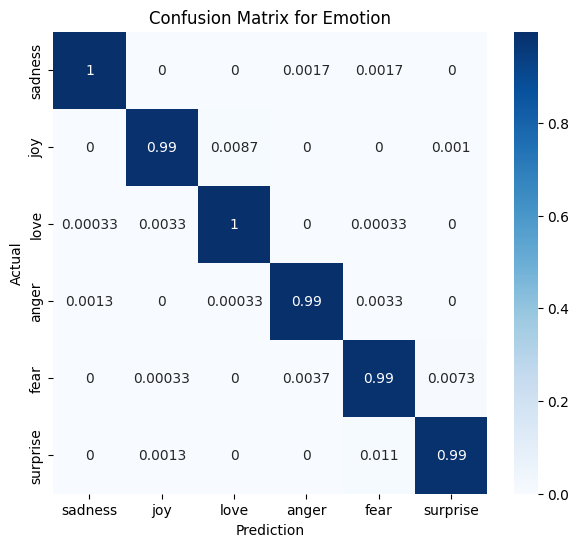

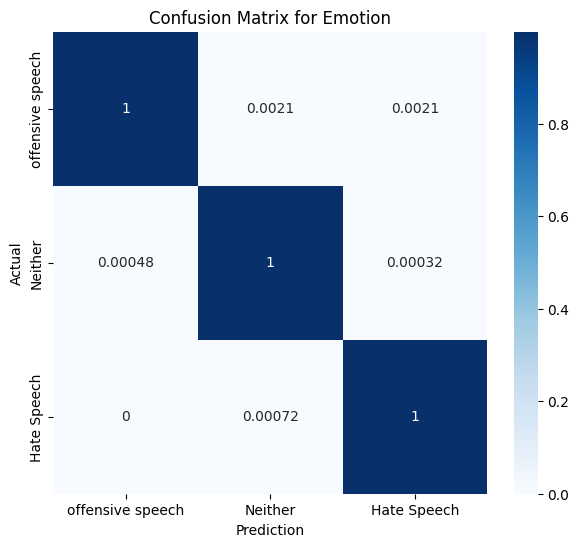

In [ ]:
plot_cm(emotion_labels, emotion_pred, 'Confusion Matrix for Emotion', emotion_labels_text)
plot_cm(hate_labels, hate_pred, 'Confusion Matrix for Emotion', hate_labels_text)